In [3]:
pip install pandas openpyxl cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 96.8 MB/s eta 0:00:00


In [7]:
df=pd.read_excel("/content/cyclone_data.xlsx")

In [8]:
df.columns = df.columns.str.strip()

In [9]:

# Strip whitespace, convert to string, treat NaN as empty string
lat = df["Latitude"].fillna("").astype(str).str.strip()

# Filter: length strictly greater than 5
filtered = df[lat.str.len() > 5].copy()

filtered.to_excel("latitude_filtered_data.xlsx", index=False)

In [11]:
import pandas as pd

lat = df["Latitude"].fillna("").astype(str).str.strip()
df["Latitude"] = df["Latitude"].fillna("").astype(str).str.strip()

# Find indexes of rows to remove
rows_to_drop = df[df["Latitude"].str.len() > 5].index

# Drop them
df = df.drop(index=rows_to_drop)

df.to_excel("cleaned_data.xlsx", index=False)

In [13]:
df_cleaned=pd.read_excel("/content/cleaned_data.xlsx")

In [14]:
df_cleaned

,Serial Number,Basin of origin,Name,Date,Time,Latitude,Longitude,CI No,Estimated Central Pressure (hPa),Maximum Sustained Surface Wind (kt),Pressure_drop_(hPa),Grade,outermost_closed_isobar_(hPa),diameter_size_of_outermost_closed_isobar,Year,Unnamed: 15,Unnamed: 16
0,1.0,BOB,NaN,1982-05-01 00:00:00,0300,14.0,82.5,1.5,NaN,25,3,D,NaN,NaN,1982,NaN,NaN
1,1.0,BOB,NaN,1982-05-01 00:00:00,0600,14.5,82.5,2.0,NaN,30,5,DD,NaN,NaN,1982,NaN,NaN
2,1.0,BOB,NaN,1982-05-01 00:00:00,1200,15.0,82,2.5,NaN,35,6,CS,NaN,NaN,1982,NaN,NaN
3,1.0,BOB,NaN,1982-05-01 00:00:00,1800,15.5,82.5,2.5,NaN,40,8,CS,NaN,NaN,1982,NaN,NaN
4,1.0,BOB,NaN,1982-05-02 00:00:00,0000,16.0,83,3.0,NaN,45,10,CS,NaN,NaN,1982,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8378,NaN,BOB,NaN,2026-01-10 00:00:00,0300,9.1,81.2,1.5,1006,25,4,D,NaN,NaN,2026,NaN,NaN
8379,NaN,BOB,NaN,2026-01-10 00:00:00,0600,9.2,81,1.5,1006,25,3,D,NaN,NaN,2026,NaN,NaN
8380,NaN,BOB,NaN,2026-01-10 00:00:00,Crossed northeast Sri Lanka coast close to Mul...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,NaN,NaN
8381,NaN,BOB,NaN,2026-01-10 00:00:00,1200,9.3,80.8,1.5,1007,25,3,D,NaN,NaN,2026,NaN,NaN


In [20]:
to_remove = df_cleaned[mask].copy()

# Flag which rows are empty (after normalize, empty = "")
name_empty = to_remove["Name"].eq("")
time_empty = to_remove["Time"].eq("")

print(f"Total matched rows:              {len(to_remove)}")
print(f"  Name is empty/NaN:             {name_empty.sum()}")
print(f"  Time is empty/NaN:             {time_empty.sum()}")
print(f"  BOTH empty (fully blank row):  {(name_empty & time_empty).sum()}")
print(f"  Rows with real data at least one col: {(~(name_empty & time_empty)).sum()}")

Total matched rows:              21
  Name is empty/NaN:             0
  Time is empty/NaN:             21
  BOTH empty (fully blank row):  0
  Rows with real data at least one col: 21


In [19]:
to_remove.to_excel("rows_to_check.xlsx", index=False)
print("Open 'rows_to_check.xlsx' to review before deleting.")

Open 'rows_to_check.xlsx' to review before deleting.


In [24]:
import pandas as pd

df_cleaned = pd.read_excel("cleaned_data.xlsx")

# Normalize
df_cleaned["Time"] = df_cleaned["Time"].fillna("").astype(str).str.strip()
df_cleaned["Name"] = df_cleaned["Name"].fillna("").astype(str).str.strip()

# Mask: rows where BOTH Time AND Date length > 10
mask = (df_cleaned["Time"].str.len() > 10) | (df_cleaned["Name"].str.len() > 10)

# Filtered output
filtered = df_cleaned[mask]

print(f"Rows matching: {len(filtered)}")
print(filtered.head(20))

filtered.to_excel("name_timefiltered_output.xlsx", index=False)

Rows matching: 115
      Serial Number Basin of origin  \
2977            NaN             NaN   
2978            NaN             NaN   
3606            NaN             NaN   
3731            8.0             BOB   
3790            NaN             NaN   
3836            NaN             NaN   
3914            3.0             BOB   
3936            NaN             NaN   
3972            NaN             NaN   
3973            NaN             NaN   
4019            NaN             NaN   
4020            NaN             NaN   
4071            NaN             NaN   
4072            NaN             NaN   
4073            NaN             NaN   
4099            NaN             NaN   
4100            NaN             NaN   
4123            NaN             NaN   
4128            NaN             NaN   
4133            NaN             NaN   

                                                   Name Date Time Latitude  \
2977  THE SYSTEM WEAKENED RAPIDLY INTO A WELL MARKED...  NaN           NaN   
2978 

In [25]:
import pandas as pd

df_cleaned = pd.read_excel("cleaned_data.xlsx")

# Normalize
df_cleaned["Time"] = df_cleaned["Time"].fillna("").astype(str).str.strip()
df_cleaned["Name"] = df_cleaned["Name"].fillna("").astype(str).str.strip()

# Mask: rows where Time OR Name length > 10
mask = (df_cleaned["Time"].str.len() > 10) | (df_cleaned["Name"].str.len() > 10)

# Rows to REMOVE (the matched ones)
removed = df_cleaned[mask]

# Rows to KEEP (everything else)
df_cleaned = df_cleaned[~mask].reset_index(drop=True)

print(f"Rows removed:   {len(removed)}")
print(f"Rows remaining: {len(df_cleaned)}")

# Save both — kept data + removed data (for audit)
df_cleaned.to_excel("final_output.xlsx", index=False)
# removed.to_excel("name_timefiltered_output.xlsx", index=False)

Rows removed:   115
Rows remaining: 8268


In [26]:
import pandas as pd

df_cleaned = pd.read_excel("final_output.xlsx")

# Normalize ALL columns (so empty/NaN become "")
df_norm = df_cleaned.fillna("").astype(str).apply(lambda c: c.str.strip())

# All columns EXCEPT Year
other_cols = [c for c in df_norm.columns if c != "Year"]

# Mask: Year has a value  AND  all other columns are empty
year_filled   = df_norm["Year"].ne("")
others_empty  = df_norm[other_cols].eq("").all(axis=1)

mask = year_filled & others_empty

filtered = df_cleaned[mask]

print(f"Total rows:                      {len(df_cleaned)}")
print(f"Rows where ONLY Year is filled:  {len(filtered)}")
print(filtered.head(20))

filtered.to_excel("year_only_rows.xlsx", index=False)

Total rows:                      8268
Rows where ONLY Year is filled:  504
      Serial Number Basin of origin Name Date  Time Latitude Longitude CI No  \
1982            NaN             NaN  NaN  NaN   NaN      NaN       NaN   NaN   
1983            NaN             NaN  NaN  NaN   NaN      NaN       NaN   NaN   
1989            NaN             NaN  NaN  NaN   NaN      NaN       NaN   NaN   
1990            NaN             NaN  NaN  NaN   NaN      NaN       NaN   NaN   
2025            NaN             NaN  NaN  NaN   NaN      NaN       NaN   NaN   
2026            NaN             NaN  NaN  NaN   NaN      NaN       NaN   NaN   
2027            NaN             NaN  NaN  NaN   NaN      NaN       NaN   NaN   
2033            NaN             NaN  NaN  NaN   NaN      NaN       NaN   NaN   
2034            NaN             NaN  NaN  NaN   NaN      NaN       NaN   NaN   
2035            NaN             NaN  NaN  NaN   NaN      NaN       NaN   NaN   
2036            NaN             NaN  NaN  NaN

In [28]:
import pandas as pd

df_cleaned = pd.read_excel("final_output.xlsx")

# Normalize ALL columns
df_norm = df_cleaned.fillna("").astype(str).apply(lambda c: c.str.strip())

# All columns EXCEPT Year
other_cols = [c for c in df_norm.columns if c != "Year"]

# Mask: Year has a value AND all other columns are empty
year_filled  = df_norm["Year"].ne("")
others_empty = df_norm[other_cols].eq("").all(axis=1)

mask = year_filled & others_empty

# Rows matching (to remove)
filtered = df_cleaned[mask]

# ---- REMOVE them ----
df_cleaned_input = df_cleaned[~mask].reset_index(drop=True)

print(f"Total rows:                      {len(df_cleaned)}")
print(f"Rows where ONLY Year is filled:  {len(filtered)}")
print(f"Rows removed:                    {len(filtered)}")
print(f"Rows remaining:                  {len(df_cleaned_input)}")

# Save removed rows (for audit)
filtered.to_excel("year_only_rows.xlsx", index=False)

# Save cleaned remaining data
df_cleaned_input.to_excel("df_cleaned_input.xlsx", index=False)

print("\nSaved:")
print("  year_only_rows.xlsx     → removed rows")
print("  df_cleaned_input.xlsx   → remaining cleaned data")

Total rows:                      8268
Rows where ONLY Year is filled:  504
Rows removed:                    504
Rows remaining:                  7764

Saved:
  year_only_rows.xlsx     → removed rows
  df_cleaned_input.xlsx   → remaining cleaned data


In [29]:
import pandas as pd

df_cleaned_input = pd.read_excel("df_cleaned_input.xlsx")

# Null count per column
null_counts = df_cleaned_input.isnull().sum()
print(null_counts)

Serial Number                               2265
Basin of origin                               14
Name                                        4080
Date                                         698
Time                                         195
Latitude                                     216
Longitude                                    227
CI No                                        276
Estimated Central Pressure (hPa)             714
Maximum Sustained Surface Wind (kt)          224
Pressure_drop_(hPa)                          366
Grade                                        242
outermost_closed_isobar_(hPa)               5284
diameter_size_of_outermost_closed_isobar    6773
Year                                           0
Unnamed: 15                                 7764
Unnamed: 16                                 7763
dtype: int64


In [32]:
import pandas as pd

df = pd.read_excel("df_cleaned_input.xlsx")

lat = df["Latitude"].astype(str).str.strip().str.lower()
lon = df["Longitude"].astype(str).str.strip().str.lower()

lat_missing = df["Latitude"].isnull() | lat.isin(["", "nan", "none"])
lon_missing = df["Longitude"].isnull() | lon.isin(["", "nan", "none"])

# Filter rows where Latitude OR Longitude is missing
df_missing = df[lat_missing | lon_missing].copy()

# ---- Check wind column ----
wind_col = "Maximum Sustained Surface Wind (kt)"

print(f"Rows in df_missing: {len(df_missing)}")
print(f"Column exists:      {wind_col in df.columns}")
print()

# Wind nulls / empties
wind = df_missing[wind_col].astype(str).str.strip().str.lower()
wind_missing = df_missing[wind_col].isnull() | wind.isin(["", "nan", "none"])

print(f"Wind HAS value:     {(~wind_missing).sum()}")
print(f"Wind is empty/NaN:  {wind_missing.sum()}")
print()

# Show the rows
print(df_missing[["Latitude", "Longitude", wind_col]].head(30))

Rows in df_missing: 232
Column exists:      True

Wind HAS value:     18
Wind is empty/NaN:  214

     Latitude Longitude Maximum Sustained Surface Wind (kt)
87        NaN        83                                  30
506       WML       NaN                                 NaN
518       WML       NaN                                 NaN
555       WML       NaN                                 NaN
565       WML       NaN                                 NaN
1339      NaN       NaN                                  25
1468      NaN       NaN                                  30
1469      NaN       NaN                                  35
1981      WML       NaN                                 NaN
2020      NaN       NaN                                 NaN
2051      NaN       NaN                                 NaN
2067      NaN       NaN                                 NaN
2073      NaN       NaN                                 NaN
2074      NaN       NaN                                 NaN
21

In [31]:
import pandas as pd

df = pd.read_excel("df_cleaned_input.xlsx")

lat = df["Latitude"].astype(str).str.strip().str.lower()
lon = df["Longitude"].astype(str).str.strip().str.lower()

lat_missing = df["Latitude"].isnull() | lat.isin(["", "nan", "none"])
lon_missing = df["Longitude"].isnull() | lon.isin(["", "nan", "none"])

# Filter — rows where Latitude OR Longitude is missing
df_missing = df[lat_missing | lon_missing]

print(f"Rows: {len(df_missing)}")
print(df_missing)

Rows: 232
      Serial Number Basin of origin   Name                 Date    Time  \
87             10.0             BOB    NaN  1982-10-17 00:00:00   300.0   
506             7.0             BOB    NaN  1990-11-04 00:00:00  1200.0   
518             1.0             ARB    NaN  1990-11-18 00:00:00   600.0   
555             1.0             ARB      -  1993-11-16 00:00:00     0.0   
565             2.0             ARB    NaN  1993-11-10 00:00:00     0.0   
...             ...             ...    ...                  ...     ...   
6708            NaN             BOB  JAWAD                  NaN     NaN   
6742            NaN             BOB    NaN                  NaN     NaN   
6792            NaN              AS    NaN                  NaN     NaN   
7257            NaN             NaN    NaN                  NaN     NaN   
7351            NaN  *Reintensified    NaN                  NaN     NaN   

     Latitude                                          Longitude CI No  \
87        NaN  

In [34]:
import pandas as pd

df = pd.read_excel("df_cleaned_input.xlsx")

lat = df["Latitude"].astype(str).str.strip().str.lower()
lon = df["Longitude"].astype(str).str.strip().str.lower()

lat_missing = df["Latitude"].isnull() | lat.isin(["", "nan", "none"])
lon_missing = df["Longitude"].isnull() | lon.isin(["", "nan", "none"])

# All rows where Latitude OR Longitude is missing — ALL COLUMNS
df_missing = df[lat_missing | lon_missing].copy()

print(f"Rows with missing Lat/Long: {len(df_missing)}")
print(f"Columns: {list(df_missing.columns)}")
print()
print(df_missing)


df_missing.to_excel("all_missing_latlong.xlsx", index=False)
print(f"Saved {len(df_missing)} rows → all_missing_latlong.xlsx")

Rows with missing Lat/Long: 232
Columns: ['Serial Number', 'Basin of origin', 'Name', 'Date', 'Time', 'Latitude', 'Longitude', 'CI No', 'Estimated Central Pressure (hPa)', 'Maximum Sustained Surface Wind (kt)', 'Pressure_drop_(hPa)', 'Grade', 'outermost_closed_isobar_(hPa)', 'diameter_size_of_outermost_closed_isobar', 'Year', 'Unnamed: 15', 'Unnamed: 16']

      Serial Number Basin of origin   Name                 Date    Time  \
87             10.0             BOB    NaN  1982-10-17 00:00:00   300.0   
506             7.0             BOB    NaN  1990-11-04 00:00:00  1200.0   
518             1.0             ARB    NaN  1990-11-18 00:00:00   600.0   
555             1.0             ARB      -  1993-11-16 00:00:00     0.0   
565             2.0             ARB    NaN  1993-11-10 00:00:00     0.0   
...             ...             ...    ...                  ...     ...   
6708            NaN             BOB  JAWAD                  NaN     NaN   
6742            NaN             BOB    Na

In [35]:
import pandas as pd

# ---- Load ----
df = pd.read_excel("df_cleaned_input.xlsx")

# ---- Build missing mask ----
lat = df["Latitude"].astype(str).str.strip().str.lower()
lon = df["Longitude"].astype(str).str.strip().str.lower()

lat_missing = df["Latitude"].isnull() | lat.isin(["", "nan", "none"])
lon_missing = df["Longitude"].isnull() | lon.isin(["", "nan", "none"])

mask = lat_missing | lon_missing

# ---- Rows to remove / rows to keep ----
removed = df[mask].copy()
df_final = df[~mask].reset_index(drop=True)

print("=" * 55)
print(f"Original rows:                 {len(df)}")
print(f"Rows removed (missing lat/lon):{len(removed)}")
print(f"Rows remaining:                {len(df_final)}")
print("=" * 55)

# ---- Save outputs ----
df_final.to_excel("df_final_no_missing_latlong.xlsx", index=False)
# removed.to_excel("removed_missing_latlong.xlsx", index=False)

print("\nSaved:")
print("  df_final_no_missing_latlong.xlsx  → cleaned data")
print("  removed_missing_latlong.xlsx      → removed rows")

Original rows:                 7764
Rows removed (missing lat/lon):232
Rows remaining:                7532

Saved:
  df_final_no_missing_latlong.xlsx  → cleaned data
  removed_missing_latlong.xlsx      → removed rows


In [36]:
import pandas as pd

df_cleaned_input = pd.read_excel("df_final_no_missing_latlong.xlsx")

# Null count per column
null_counts = df_cleaned_input.isnull().sum()
print(null_counts)

Serial Number                               2092
Basin of origin                                2
Name                                        3874
Date                                         528
Time                                           0
Latitude                                       0
Longitude                                      0
CI No                                         79
Estimated Central Pressure (hPa)             499
Maximum Sustained Surface Wind (kt)           10
Pressure_drop_(hPa)                          152
Grade                                         25
outermost_closed_isobar_(hPa)               5054
diameter_size_of_outermost_closed_isobar    6541
Year                                           0
Unnamed: 15                                 7532
Unnamed: 16                                 7531
dtype: int64


In [40]:
import pandas as pd

# ---------- 1. LOAD ----------
df_cleaned_input = pd.read_excel("df_cleaned_input.xlsx")
total_original = len(df_cleaned_input)

# ---------- 2. FILL WIND NULLS WITH 0 ----------
wind_col = "Maximum Sustained Surface Wind (kt)"

# Treat blank strings as NaN too, then fill
df_cleaned_input[wind_col] = (
    df_cleaned_input[wind_col]
    .replace(r"^\s*$", pd.NA, regex=True)
    .fillna(0)
)

wind_filled_count = df_cleaned_input[wind_col].eq(0).sum()

# ---------- 3. BUILD NULL REPORT ON ORIGINAL ----------
null_count  = df_cleaned_input.isnull().sum()
empty_count = (df_cleaned_input.astype(str).apply(lambda c: c.str.strip()) == "").sum()

report = pd.DataFrame({
    "Column":        df_cleaned_input.columns,
    "Null_NaN":      null_count.values,
    "Empty_String":  empty_count.values,
})
report["Total_Missing"] = report["Null_NaN"] + report["Empty_String"]
report["Percent"]       = (report["Total_Missing"] / total_original * 100).round(2)
report["Total_Rows"]    = total_original

# ---------- 4. SAVE ALL TO ONE EXCEL FILE ----------
with pd.ExcelWriter("final_output_2.xlsx", engine="openpyxl") as writer:
    df_cleaned_input.to_excel(writer, sheet_name="Cleaned_Data", index=False)
    report.to_excel(writer,           sheet_name="Null_Report",  index=False)

# ---------- 5. CONSOLE SUMMARY ----------
print("=" * 60)
print(f"Total rows:                    {total_original}")
print(f"Wind nulls filled with 0:      {wind_filled_count}")
print("=" * 60)
print("\nNull Report:")
print(report.to_string(index=False))
print("\nSaved → final_output.xlsx")
print("  Sheet 'Cleaned_Data' : filled data")
print("  Sheet 'Null_Report'  : per-column null counts")

Total rows:                    7764
Wind nulls filled with 0:      257

Null Report:
                                  Column  Null_NaN  Empty_String  Total_Missing  Percent  Total_Rows
                           Serial Number      2265             0           2265    29.17        7764
                         Basin of origin        14             0             14     0.18        7764
                                    Name      4080             0           4080    52.55        7764
                                    Date       698             0            698     8.99        7764
                                    Time       195             0            195     2.51        7764
                                Latitude       216             0            216     2.78        7764
                               Longitude       227             0            227     2.92        7764
                                   CI No       276             0            276     3.55        7764
      

In [43]:
import pandas as pd

# Show all columns, no truncation
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 40)

df = pd.read_excel("final_output_2.xlsx")

# Normalize both
lat = df["Latitude"].astype(str).str.strip().str.lower()
lon = df["Longitude"].astype(str).str.strip().str.lower()

# Null masks
lat_missing = df["Latitude"].isnull() | lat.isin(["", "nan", "none"])
lon_missing = df["Longitude"].isnull() | lon.isin(["", "nan", "none"])

# Rows where EITHER is null
mask = lat_missing | lon_missing

df_missing_latlon = df[mask].copy()

print(f"Total rows:                       {len(df)}")
print(f"Latitude null:                    {lat_missing.sum()}")
print(f"Longitude null:                   {lon_missing.sum()}")
print(f"Lat OR Lon null (total):          {len(df_missing_latlon)}")
print("=" * 120)
print(df_missing_latlon.to_string())
print("=" * 120)

df_missing_latlon.to_excel("missing_latlon_rows.xlsx", index=False)
print(f"Saved {len(df_missing_latlon)} rows → missing_latlon_rows.xlsx")

Total rows:                       7764
Latitude null:                    216
Longitude null:                   227
Lat OR Lon null (total):          232
      Serial Number                                                                                                         Basin of origin     Name                                                                                                           Date    Time Latitude                                                                  Longitude                                                                                                                                            CI No                                                      Estimated Central Pressure (hPa)                                                                     Maximum Sustained Surface Wind (kt)                                                                                                                Pressure_drop_(hPa)     Grade outermost_closed_is

In [44]:
import pandas as pd

# Show all columns, no truncation
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 40)

df = pd.read_excel("final_output_2.xlsx")

# Normalize both
lat = df["Latitude"].astype(str).str.strip().str.lower()
lon = df["Longitude"].astype(str).str.strip().str.lower()

# Null masks
lat_missing = df["Latitude"].isnull() | lat.isin(["", "nan", "none"])
lon_missing = df["Longitude"].isnull() | lon.isin(["", "nan", "none"])

# Rows where EITHER is null
mask = lat_missing | lon_missing

# Rows to remove
df_missing_latlon = df[mask].copy()

# Rows to KEEP (remove missing)
final_data_cleaned = df[~mask].reset_index(drop=True)

print(f"Total rows:                       {len(df)}")
print(f"Latitude null:                    {lat_missing.sum()}")
print(f"Longitude null:                   {lon_missing.sum()}")
print(f"Lat OR Lon null (removed):        {len(df_missing_latlon)}")
print(f"Rows remaining:                   {len(final_data_cleaned)}")
print("=" * 120)

# Save both — removed rows (audit) + cleaned data
df_missing_latlon.to_excel("missing_latlon_rows.xlsx", index=False)
final_data_cleaned.to_excel("final_data_cleaned.xlsx", index=False)

print(f"\nSaved {len(df_missing_latlon)} removed rows → missing_latlon_rows.xlsx")
print(f"Saved {len(final_data_cleaned)} cleaned rows → final_data_cleaned.xlsx")

Total rows:                       7764
Latitude null:                    216
Longitude null:                   227
Lat OR Lon null (removed):        232
Rows remaining:                   7532

Saved 232 removed rows → missing_latlon_rows.xlsx
Saved 7532 cleaned rows → final_data_cleaned.xlsx


In [49]:
import pandas as pd

df_cleaned = pd.read_excel("final_data_cleaned.xlsx")

df.isna().sum()

,0
Serial Number,2092
Basin of origin,2
Name,3874
Date,528
Time,0
Latitude,0
Longitude,0
CI No,79
Estimated Central Pressure (hPa),499
Maximum Sustained Surface Wind (kt),0


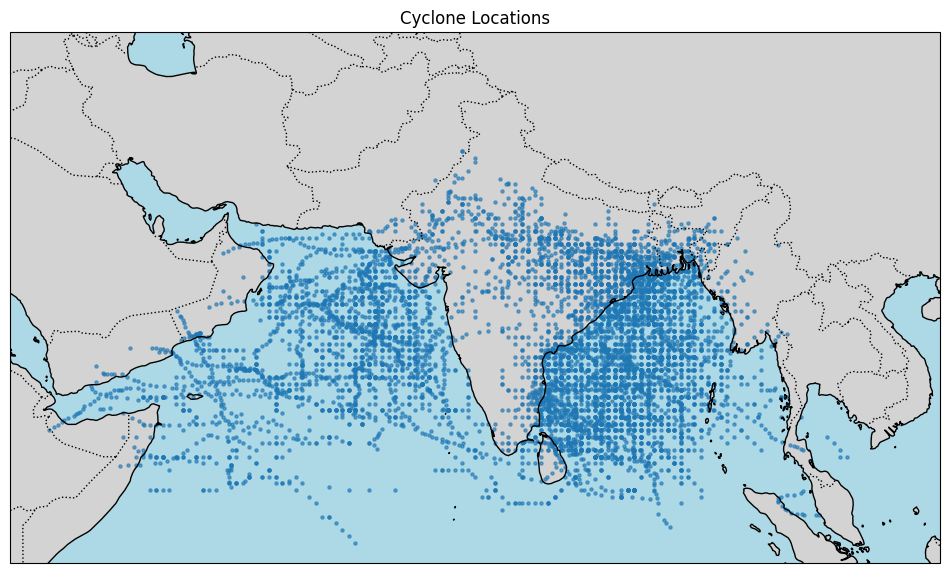

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Convert coordinates to numeric
df_cleaned["Latitude"] = pd.to_numeric(
    df_cleaned["Latitude"], errors="coerce"
)
df_cleaned["Longitude"] = pd.to_numeric(
    df_cleaned["Longitude"], errors="coerce"
)

# Remove invalid coordinates
df_map = df_cleaned.dropna(
    subset=["Latitude", "Longitude"]
).copy()

# Create map
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Plot cyclone locations
ax.scatter(
    df_map["Longitude"],
    df_map["Latitude"],
    s=5,
    alpha=0.6,
    transform=ccrs.PlateCarree()
)

ax.set_extent([40, 110, 0, 40], crs=ccrs.PlateCarree())
ax.set_title("Cyclone Locations")

plt.show()

In [51]:
import pandas as pd

df = pd.read_excel("final_data_cleaned.xlsx")
df.to_csv("final_data_cleaned.csv", index=False)

print(f"Saved {len(df)} rows → final_data_cleaned.csv")

Saved 7532 rows → final_data_cleaned.csv
